# Решение задачи C

Обработка отзывов с помощью нейросетевой модели с hugging face. На кагле иногда не работала подгрузка модели с hugging face из-за странной ошибки. Обработка выполнялась единоразово, потом эти эмбединги сохранил и с каждой новой сессией подгружались в переменную

Во всех подгрузках файлов надо поменять пути на правильные

In [1]:
!pip install --upgrade transformers huggingface_hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 93.1 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.3/564.3 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 83.5 MB/s eta 0:00:00:00:01
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface-hub 1.0.0rc2
    Uninstalling huggingface-hub-1.0.0rc2:
      Successfully uninstalled huggingface-hub-1.0.0rc2
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.2
    Uninstalling tokenizers-0.21.2:
      Successfully uninstalled tokenizers-0.21.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.53.3
    Uninstalling transformers-4.53.3:
      Successfully uninstalled transformers-4.53.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour

In [2]:
from transformers import AutoTokenizer, AutoModel
import torch
import pandas as pd
df = pd.read_csv('/kaggle/input/vseros-geo-data/reviews.txv/reviews.tsv', sep='\t')

In [3]:
from transformers import AutoTokenizer, AutoModel
import torch
import pandas as pd
from tqdm import tqdm
import numpy as np
model_name = "intfloat/multilingual-e5-large"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

2025-10-15 08:01:46.284884: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760515306.472695      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760515306.527399      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(250037, 384, padding_idx=0)
    (position_embeddings): Embedding(512, 384)
    (token_type_embeddings): Embedding(2, 384)
    (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=384, out_features=384, bias=True)
            (key): Linear(in_features=384, out_features=384, bias=True)
            (value): Linear(in_features=384, out_features=384, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=384, out_features=384, bias=True)
            (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=Fals

Последний эксперимент был с small моделью (6 минут), но в итоговом лучшем решении large

In [4]:
batch_size = 128
def embed_texts(texts):
    prefixed = ["passage: " + t for t in texts]
    encoded = tokenizer(prefixed, padding=True, truncation=True, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**encoded)
    embeddings = outputs.last_hidden_state.mean(dim=1)
    return embeddings.cpu().numpy()

embeddings_dict = {}
texts = df["text"].tolist()
ids = df["id"].tolist()

for i in tqdm(range(0, len(df), batch_size), desc="Encoding batches"):
    batch_texts = texts[i:i + batch_size]
    batch_ids = ids[i:i + batch_size]
    batch_embeddings = embed_texts(batch_texts)
    
    for uid, emb in zip(batch_ids, batch_embeddings):
        embeddings_dict.setdefault(uid, []).append(emb)

# Усреднение эмбедингов заведений по их айди
id_mean_embeddings = {uid: np.mean(vecs, axis=0) for uid, vecs in embeddings_dict.items()}

Encoding batches: 100%|██████████| 3439/3439 [06:15<00:00,  9.15it/s]


In [ ]:
import numpy as np
np.savez("id_mean_embeddings_vseros_geo_large.npz", **{str(k): v for k, v in id_mean_embeddings.items()})
print("Эмбеддинги сохранены в id_mean_embeddings.npz")

В итоге был сохранён словарь вида id: усреднённые эмбединги всех отзывов по id

Затем я подумал, что хорошей фичей будет сентиментальный анализ отзывов от другой модели, что я также делал единоразово и потом подгружал

In [3]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from tqdm.auto import tqdm
import torch

MODEL_NAME = "blanchefort/rubert-base-cased-sentiment"

device = 0 if torch.cuda.is_available() else -1
print(f"Используется устройство: {'CUDA' if device == 0 else 'CPU'}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

sentiment_pipe = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    device=device,
    truncation=True,
    max_length=256
)

texts = df["text"].fillna("").tolist()

batch_size = 32
results = []
for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i:i + batch_size]
    outputs = sentiment_pipe(batch, batch_size=batch_size)
    results.extend(outputs)

df["sentiment_label"] = [r["label"] for r in results]
df["sentiment_score"] = [r["score"] for r in results]

2025-10-16 15:02:28.628286: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760626948.807785      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760626948.857971      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Используется устройство: CUDA


tokenizer_config.json:   0%|          | 0.00/499 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/943 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/711M [00:00<?, ?B/s]

Device set to use cuda:0


  0%|          | 0/13753 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,text,sentiment_label,sentiment_score,sentiment_num
0,43591,"Мармелад в целом неплохой, но цены завышены, м...",NEUTRAL,0.694134,NaN
1,43591,"Не нравится, что товар выложен открыто, слишко...",NEUTRAL,0.778578,NaN
2,43591,"Часто попадается сухой мармелад, дубовый впере...",NEUTRAL,0.797100,NaN
3,43591,"Персонал был одет в костюмы пиратов, а ассорти...",POSITIVE,0.981319,NaN
4,43591,"Вкусный мармелад с широким ассортиментом форм,...",POSITIVE,0.978763,NaN


In [12]:
label_to_num = {"NEGATIVE": -1, "NEUTRAL": 0, "POSITIVE": 1}
df["sentiment_num"] = df["sentiment_label"].map(label_to_num) * df["sentiment_score"]

df.head()

,id,text,sentiment_label,sentiment_score,sentiment_num
0,43591,"Мармелад в целом неплохой, но цены завышены, м...",NEUTRAL,0.694134,0.000000
1,43591,"Не нравится, что товар выложен открыто, слишко...",NEUTRAL,0.778578,0.000000
2,43591,"Часто попадается сухой мармелад, дубовый впере...",NEUTRAL,0.797100,0.000000
3,43591,"Персонал был одет в костюмы пиратов, а ассорти...",POSITIVE,0.981319,0.981319
4,43591,"Вкусный мармелад с широким ассортиментом форм,...",POSITIVE,0.978763,0.978763


In [13]:
df.to_csv('vseros-geo-sentiments.csv')

Библиотека с нейросетевой моделью для табличных данных

In [1]:
!pip install tabm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 104.2 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 27.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 86.8 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed

Подгрузка эмбедингов из файла. Для воспроизводимости надо поменять путь на свой правильный, файл должен быть на диске (код для генерации файлов выше)

In [ ]:
import numpy as np
data = np.load("/kaggle/input/vseros-geo-data/id_mean_embeddings_vseros_geo_large.npz")
id_mean_embeddings = {str(k): data[k] for k in data.files}

Здесь также стоит просто поменять пути на правильные

In [64]:
import pandas as pd
train = pd.read_csv('/kaggle/input/vseros-geo-data/train.tsv', sep='\t')
test = pd.read_csv('/kaggle/input/vseros-geo-data/test.tsv', sep='\t')

Разные простые текстовые фичи

In [65]:
reviews = pd.read_csv('/kaggle/input/vseros-geo-data/reviews.txv/reviews.tsv', sep='\t')
reviews['text_len'] = reviews['text'].apply(len)
reviews['excl_marks'] = reviews['text'].str.count('!')
reviews['question_marks'] = reviews['text'].str.count('\?')
reviews['dots'] = reviews['text'].str.count('\.')
reviews['commas'] = reviews['text'].str.count(',')
reviews['caps_count'] = reviews['text'].str.count(r'[A-ZА-Я]')
reviews['word_count'] = reviews['text'].str.split().apply(len)
reviews['avg_word_len'] = reviews['text'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0
)
reviews['unique_word_ratio'] = reviews['text'].apply(
    lambda x: len(set(x.split())) / len(x.split()) if len(x.split()) > 0 else 0
)
reviews['digit_count'] = reviews['text'].str.count(r'\d')
reviews['uppercase_ratio'] = reviews['text'].apply(
    lambda x: sum(1 for ch in x if ch.isupper()) / len(x) if len(x) > 0 else 0
)
reviews_features = reviews.groupby('id').agg({
    'text': ['count'],
    'text_len': ['mean', 'std', 'sum'],
    'word_count': ['mean', 'std', 'sum'],
    'excl_marks': ['mean', 'sum', 'std'],
    'question_marks': ['mean', 'sum', 'std'],
    'unique_word_ratio': ['mean', 'sum', 'std'],
    'uppercase_ratio': ['mean', 'sum', 'std']
}).reset_index()

In [66]:
reviews_features.columns = [
    '_'.join(col) if isinstance(col, tuple) else col
    for col in reviews_features.columns
]

In [67]:
reviews_features = reviews_features.rename(columns={'id_':'id'})

In [68]:
train = train.merge(reviews_features, on='id', how='left')
test = test.merge(reviews_features, on='id', how='left')

Фичи из анализа сентимента

In [69]:
sent_df = pd.read_csv('/kaggle/input/vseros-geo-data/vseros-geo-sentiments.csv')
sentiment_counts = (
    sent_df.pivot_table(
        index="id",
        columns="sentiment_label",
        values="text", 
        aggfunc="count",
        fill_value=0
    )
    .rename(columns=lambda c: f"count_{c.lower()}")
)

sentiment_counts["count_total"] = sentiment_counts.sum(axis=1)
for col in ["count_negative", "count_neutral", "count_positive"]:
    sentiment_counts[f"ratio_{col.split('_')[1]}"] = (
        sentiment_counts[col] / sentiment_counts["count_total"]
    )

sentiment_mean = sent_df.groupby("id")["sentiment_num"].mean().rename("mean_sentiment_num")

sentiment_stats = sentiment_counts.join(sentiment_mean)

sentiment_stats.reset_index(inplace=True)
train = train.merge(sentiment_stats, on='id', how='left')
test = test.merge(sentiment_stats, on='id', how='left')

Много смысловых фичей из исходных (feature engineering)

In [74]:
import ast
import numpy as np
import pandas as pd
from typing import Optional


def feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    EPS = 1e-9
    res = df.copy()
    
    for col in res.columns:
        if col.endswith("_300m") or col.endswith("_1000m"):
            res[col] = pd.to_numeric(res[col], errors="coerce")
    
    def safe_div(a, b, eps=EPS):
        return a / (b + eps)
    
    if "coordinates" in res.columns:
        def parse_xy(v):
            if isinstance(v, (list, tuple)) and len(v) == 2:
                return v[0], v[1]
            if isinstance(v, str):
                try:
                    vv = ast.literal_eval(v)
                    if isinstance(vv, (list, tuple)) and len(vv) == 2:
                        return vv[0], vv[1]
                except:
                    pass
            return np.nan, np.nan
        
        xy = res["coordinates"].apply(parse_xy)
        res[["fe_x", "fe_y"]] = pd.DataFrame(xy.tolist(), index=res.index)
    
    for r in [300, 1000]:
        homes = res.get(f"homes_{r}m", 0)
        works = res.get(f"works_{r}m", 0)
        traffic = res.get(f"traffic_{r}m", 0)
        
        people = homes + works
        res[f"fe_people_{r}m"] = people
        res[f"fe_activity_intensity_{r}m"] = safe_div(traffic, people)
        res[f"fe_residential_share_{r}m"] = safe_div(homes, people)
        res[f"fe_day_night_index_{r}m"] = safe_div(works, homes)
    

    for r in [300, 1000]:
        female = res.get(f"female_{r}m", 0).fillna(0)
        male = res.get(f"male_{r}m", 0).fillna(0)
        total_sex = female + male
        res[f"fe_female_share_{r}m"] = safe_div(female, total_sex)
        
        has_children = res.get(f"has_children_{r}m", 0).fillna(0)
        no_children = res.get(f"no_children_{r}m", 0).fillna(0)
        res[f"fe_children_share_{r}m"] = safe_div(has_children, has_children + no_children)
        
        married = res.get(f"married_{r}m", 0).fillna(0)
        not_married = res.get(f"not_married_{r}m", 0).fillna(0)
        res[f"fe_married_share_{r}m"] = safe_div(married, married + not_married)
        
        higher = res.get(f"higher_education_{r}m", 0).fillna(0)
        no_higher = res.get(f"no_higher_education_{r}m", 0).fillna(0)
        secondary = res.get(f"secondary_education_{r}m", 0).fillna(0)
        edu_total = higher + secondary + no_higher
        res[f"fe_higher_edu_share_{r}m"] = safe_div(higher, edu_total)
        
        age_bins = {
            f"age_<17_{r}m": 12.0,
            f"age_18-24_{r}m": 21.0,
            f"age_25-34_{r}m": 29.5,
            f"age_35-44_{r}m": 39.5,
            f"age_45-54_{r}m": 49.5,
            f"age_>55_{r}m": 60.0,
        }
        age_counts = {k: res.get(k, 0).fillna(0) for k in age_bins}
        age_total = sum(age_counts.values())
        weighted_age = sum(age_counts[k] * age_bins[k] for k in age_bins)
        res[f"fe_age_avg_{r}m"] = safe_div(weighted_age, age_total)
        
        young = age_counts[f"age_<17_{r}m"] + age_counts[f"age_18-24_{r}m"]
        mid = age_counts[f"age_25-34_{r}m"] + age_counts[f"age_35-44_{r}m"]
        senior = age_counts[f"age_45-54_{r}m"] + age_counts[f"age_>55_{r}m"]
        res[f"fe_age_young_share_{r}m"] = safe_div(young, age_total)
        res[f"fe_age_senior_share_{r}m"] = safe_div(senior, age_total)
        
        inc_map = {
            f"below_average_income_{r}m": -1.0,
            f"average_income_{r}m": 0.0,
            f"above_average_income_{r}m": 1.0,
            f"high_income_{r}m": 2.0,
            f"premium_income_{r}m": 3.0,
        }
        inc_counts = {k: res.get(k, 0) for k in inc_map}
        inc_score = sum(inc_counts[k] * inc_map[k] for k in inc_map)
        inc_total = sum(inc_counts.values())
        res[f"fe_income_index_{r}m"] = safe_div(inc_score, inc_total)
    
    if "mean_income_300m" in res.columns and "mean_income_1000m" in res.columns:
        res["fe_mean_income_diff"] = res["mean_income_300m"] - res["mean_income_1000m"]
        res["fe_mean_income_ratio"] = safe_div(res["mean_income_300m"], res["mean_income_1000m"])
    

    poi_groups = {
        "food": [
            "restaurants_cafes", "restaurants_cafes_bars", "bars", "coffee_shops",
            "asian_cuisine", "italian_cuisine", "grocery_stores"
        ],
        "health": [
            "clinics", "pharmacy", "medications_and_supplements",
            "beauty_salons", "beauty_and_personal_care"
        ],
        "kids": [
            "preschool", "childrens_medicine", "childrens_books",
            "school_supplies", "children_goods", "baby_food"
        ],
        "auto": ["car_services", "car_parts"],
        "finance": [
            "banking_services", "insurance", "lending",
            "deposits", "securities_market", "microloans"
        ],
        "retail": [
            "shopping_malls", "supermarkets", "clothing_stores",
            "electronics_stores", "home_appliances"
        ],
    }
    

    all_poi = sorted(set(sum(poi_groups.values(), [])))
    
    def sum_poi(poi_list, radius):
        total = pd.Series(0.0, index=res.index)
        for poi_name in poi_list:
            col = f"{poi_name}_{radius}m"
            if col in res.columns:
                total += res[col]
        return total
    
    for r in [300, 1000]:
        people = res.get(f"fe_people_{r}m", 0)
        
        for group_name, poi_list in poi_groups.items():
            poi_sum = sum_poi(poi_list, r)
            res[f"fe_{group_name}_supply_{r}m"] = poi_sum
            res[f"fe_{group_name}_per_1k_{r}m"] = 1000.0 * safe_div(poi_sum, people)
        
        total_poi = sum_poi(all_poi, r)
        res[f"fe_poi_total_{r}m"] = total_poi
        res[f"fe_poi_per_1k_{r}m"] = 1000.0 * safe_div(total_poi, people)
        
        diversity = pd.Series(0, index=res.index)
        for poi_name in all_poi:
            col = f"{poi_name}_{r}m"
            if col in res.columns:
                diversity += (res[col] > 0).astype(int)
        res[f"fe_poi_diversity_{r}m"] = diversity
        
        has_children = res.get(f"has_children_{r}m", 0)
        kids_supply = res.get(f"fe_kids_supply_{r}m", 0)
        res[f"fe_kids_per_1k_children_{r}m"] = 1000.0 * safe_div(kids_supply, has_children)
    

    for group_name in poi_groups.keys():
        col_300 = f"fe_{group_name}_supply_300m"
        col_1000 = f"fe_{group_name}_supply_1000m"
        if col_300 in res.columns and col_1000 in res.columns:
            res[f"fe_{group_name}_local_share"] = safe_div(
                res[col_300], res[col_1000]
            )
    
    if "fe_people_300m" in res.columns and "fe_people_1000m" in res.columns:
        res["fe_people_local_share"] = safe_div(
            res["fe_people_300m"], res["fe_people_1000m"]
        )
    
    interest_groups = {
        "tech": [
            "mobile_phones", "laptops_tablets_computers", "portable_devices",
            "computer_components", "online_shops"
        ],
        "auto_interest": [
            "car_owners", "car_news", "interest_in_buying_new_car"
        ],
        "culture": [
            "movies_and_series", "books", "music", "theater"
        ],
    }
    
    for r in [300, 1000]:
        people = res.get(f"fe_people_{r}m", 0)
        for interest_name, interest_list in interest_groups.items():
            interest_sum = sum_poi(interest_list, r)
            res[f"fe_{interest_name}_per_1k_{r}m"] = 1000.0 * safe_div(interest_sum, people)
    
    for r in [300, 1000]:
        auto_supply = res.get(f"fe_auto_per_1k_{r}m", 0)
        auto_interest = res.get(f"fe_auto_interest_per_1k_{r}m", 0)
        res[f"fe_auto_supply_demand_ratio_{r}m"] = safe_div(auto_supply, auto_interest)
        
        kids_supply = res.get(f"fe_kids_per_1k_{r}m", 0)
        children_share = res.get(f"fe_children_share_{r}m", 0)
        res[f"fe_kids_coverage_{r}m"] = safe_div(kids_supply, children_share * 100)
    
    base_pairs = set()
    for col in res.columns:
        if col.endswith("_300m") and not col.startswith("fe_"):
            base = col[:-5]
            if f"{base}_1000m" in res.columns:
                base_pairs.add(base)
    
    for base in base_pairs:
        c300 = f"{base}_300m"
        c1000 = f"{base}_1000m"
        
        res[f"fe_{base}_share300"] = safe_div(res[c300], res[c1000])
        
        ring = (res[c1000] - res[c300]).clip(lower=0)
        res[f"fe_{base}_ring"] = ring
        res[f"fe_{base}_ring_share"] = safe_div(ring, res[c1000])
    
    return res

In [75]:
train = feature_engineering(train)
test = feature_engineering(test)

/tmp/ipykernel_37/3309210834.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  res[["fe_x", "fe_y"]] = pd.DataFrame(xy.tolist(), index=res.index)
/tmp/ipykernel_37/3309210834.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  res[["fe_x", "fe_y"]] = pd.DataFrame(xy.tolist(), index=res.index)
/tmp/ipykernel_37/3309210834.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(

Добавление эмбедингов отзывов к фичам

In [70]:
emb_df = pd.DataFrame([{'id': i, 'emb': j} for i, j in id_mean_embeddings.items()])

In [71]:
import numpy as np
import pandas as pd

emb_matrix = np.vstack(emb_df["emb"].values)

dim = emb_matrix.shape[1]
print(f"Размерность эмбеддингов: {dim}")

emb_cols = [f"emb_{i+1}" for i in range(dim)]

emb_df = pd.concat(
    [emb_df[["id"]].reset_index(drop=True),
     pd.DataFrame(emb_matrix, columns=emb_cols)],
    axis=1
)


Размерность эмбеддингов: 1024


In [72]:
emb_df['id'] = emb_df['id'].astype(np.int64)

In [73]:
train = pd.merge(train, emb_df, on='id', how='left')
test = pd.merge(test, emb_df, on='id', how='left')

Фичи из адреса

In [74]:
def parse_address(addr):
    try:
        m = addr.split(',')
        return {"street": m[0], "house": m[1], "city": m[-1]}
    except:
        return {"street": None, "house": None, "city": None}

parsed = train["address"].fillna('').apply(parse_address).apply(pd.Series)
parsed2 = test["address"].fillna('').apply(parse_address).apply(pd.Series)

train = pd.concat([train, parsed], axis=1)
test = pd.concat([test, parsed2], axis=1)

In [75]:
train[['coordinate_x', 'coordinate_y']] = np.stack(train['coordinates'].apply(eval).apply(np.array).values)
test[['coordinate_x', 'coordinate_y']] = np.stack(test['coordinates'].apply(eval).apply(np.array).values)
train['rasst'] = np.sqrt(train['coordinate_x'] **2 + train['coordinate_y']**2)
test['rasst'] = np.sqrt(test['coordinate_x'] **2 + test['coordinate_y']**2)

Кодирование категориальных фичей

In [76]:
from category_encoders import TargetEncoder
cat_features = train.select_dtypes(exclude=[np.number]).columns.tolist()
train[cat_features] = train[cat_features].fillna('')
test[cat_features] = test[cat_features].fillna('')
# cat_features.remove('coordinates')
cat_features.remove('address')
cat_features.remove('name')

In [77]:
train['address_text'] = train['address']
test['address_text'] = test['address']

In [78]:
te = TargetEncoder()
train[cat_features] = te.fit_transform(train[cat_features], train['target'])
test[cat_features] = te.transform(test[cat_features])

Кодирование адреса (таргет энкодинг адреса давал лик)

In [80]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(pd.concat([train['address'], test['address']]).str.lower())
train['address'] = le.transform(train['address'].str.lower())
test['address'] = le.transform(test['address'].str.lower())

In [81]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('target')

# train[num_cols] = train[num_cols].fillna(0)
# test[num_cols] = test[num_cols].fillna(0)

Удаление нулей из трейна (нет рейтинга -> не подходят нам)

In [82]:
train = train[train['target'] != 0]

In [123]:
X_test = test.copy().drop(columns=['name', 'coordinates', 'address_text'])

In [124]:
X = train.drop(columns=['target', 'name','coordinates', 'address_text'])
y = train['target']

In [125]:
cat = X['category']

TFIDF колонки name. Очень сильная фича, дала большой прирост

In [126]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy import sparse

train['name'] = train['name'].str.lower()
test['name'] = test['name'].str.lower()
all_names = pd.concat([train['name'], test['name']])
tfidf = TfidfVectorizer(
    max_features=1024,
    ngram_range=(1, 2),
    stop_words=None,
    lowercase=True
)
tfidf.fit(all_names)
train_tfidf = tfidf.transform(train['name']).toarray()
test_tfidf = tfidf.transform(test['name']).toarray()
print('TF‑IDF размерность:', train_tfidf.shape)

X = pd.DataFrame(np.hstack([X, train_tfidf]))
X_test = pd.DataFrame(np.hstack([X_test, test_tfidf]))

TF‑IDF размерность: (37167, 1024)


In [127]:
train['address_text'] = train['address_text'].apply(lambda x: x.lower().replace('.', '').replace(',', ''))
test['address_text'] = test['address_text'].apply(lambda x: x.lower().replace('.', '').replace(',', ''))

Пробовал TFIDF адреса, но по метрике не очень

In [128]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# from scipy import sparse

# all_names = pd.concat([train['address_text'], test['address_text']])
# tfidf = TfidfVectorizer(
#     max_features=128, 
#     ngram_range=(1, 2), 
#     stop_words=None,  
#     lowercase=True
# )
# tfidf.fit(all_names)
# train_tfidf = tfidf.transform(train['address_text']).toarray()
# test_tfidf = tfidf.transform(test['address_text']).toarray()
# print('TF‑IDF размерность:', train_tfidf.shape)

# X = pd.DataFrame(np.hstack([X, train_tfidf]))
# X_test = pd.DataFrame(np.hstack([X_test, test_tfidf]))

Моя функция для тренировки модели TabM. Вынесено из общего цикла для удобства и чистоты кода. Сид у TabM не фиксировал(

In [129]:
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

def train_tabm(
    X_train, y_train, X_val, y_val, X_test, cat_cols,
    device='cuda', fold=1, LR=1e-3, PATIENCE=5,
    n_blocks=4,
    d_block=128,
    k=32,
    dropout=0.0,
    attention_dropout=0.0,
    residual_dropout=0.0,
    d_out=None, 
):
    # set_seed(42)

    num_feats = X_train.shape[1] - len(cat_cols)
    cat_cardinalities = [int(X_train[col].nunique()) for col in cat_cols]
    
    if d_out is None:
        d_out = len(np.unique(y_train))

    sc = StandardScaler()
    num_cols = [i for i in X_train.columns.tolist() if i not in cat_cols]
    # num_cols = [i for i in num_cols if 'emb' not in i]
    # num_cols = [i for i in num_cols if 'tfidf' not in i]
    X_train = X_train.copy()
    X_val = X_val.copy()
    X_test = X_test.copy()
    X_train[num_cols] = X_train[num_cols].fillna(X_train[num_cols].mean())
    X_val[num_cols] = X_val[num_cols].fillna(X_train[num_cols].mean())
    X_test[num_cols] = X_test[num_cols].fillna(X_train[num_cols].mean())
    X_train[num_cols] = sc.fit_transform(X_train[num_cols])
    X_val[num_cols] = sc.transform(X_val[num_cols])
    X_test[num_cols] = sc.transform(X_test[num_cols])

    model = TabM.make(
        n_num_features=num_feats,
        cat_cardinalities=cat_cardinalities,
        d_out=1,
        n_blocks=n_blocks,
        d_block=d_block,
        k=k,
        dropout=dropout,
        # attention_dropout=attention_dropout,
        # residual_dropout=residual_dropout,
    ).to(device)

    class MAELoss(torch.nn.Module):
        def __init__(self, epsilon=1e-8):
            super(MAELoss, self).__init__()
            self.epsilon = epsilon 
    
        def forward(self, y_pred, y_true):
            loss = torch.abs(y_true - y_pred)
            return torch.mean(loss)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    criterion = MAELoss()

    X_train_num = torch.tensor(X_train.drop(columns=cat_cols).values, dtype=torch.float32, device=device)
    X_train_cat = torch.tensor(X_train[cat_cols].values, dtype=torch.long, device=device)
    y_train_t = torch.tensor(np.array(y_train), dtype=torch.float32, device=device)

    X_val_num = torch.tensor(X_val.drop(columns=cat_cols).values, dtype=torch.float32, device=device)
    X_val_cat = torch.tensor(X_val[cat_cols].values, dtype=torch.long, device=device)
    y_val_t = torch.tensor(np.array(y_val), dtype=torch.float32, device=device)

    train_ds = TensorDataset(X_train_num, X_train_cat, y_train_t)
    val_ds = TensorDataset(X_val_num, X_val_cat, y_val_t)
    train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

    best_val_score = float('inf')
    best_model_state = None
    best_val_preds = None

    patience = 0
    for epoch in range(1, 101):
        model.train()
        for xb_num, xb_cat, yb in train_loader:
            optimizer.zero_grad()
            if len(cat_cols) == 0:
                xb_cat = None
            preds_k = model(xb_num, xb_cat)
            logits_mean = preds_k.mean(dim=1).squeeze(1)
            loss = criterion(logits_mean, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        all_preds = []
        all_true = []
        all_logits = []
        with torch.no_grad():
            for xb_num, xb_cat, yb in val_loader:
                if len(cat_cols) == 0:
                    xb_cat = None
                preds_k = model(xb_num, xb_cat)
                logits_mean = preds_k.mean(dim=1).squeeze(1)
                all_preds.append(logits_mean.cpu().numpy())
                all_true.append(yb.cpu().numpy())
        all_preds = np.concatenate(all_preds)
        all_true = np.concatenate(all_true)
        all_preds = np.clip(all_preds, -20, 20)
        val_f1 = np.mean(np.abs(all_true - all_preds))
        print(f"Epoch {epoch}: TabM val_mape = {val_f1:.4f}. LB score = {(1/(1+val_f1)):.4f}")

        if val_f1 < best_val_score:
            best_val_score = val_f1
            best_model_state = {k: v.cpu() for k, v in model.state_dict().items()}
            best_val_preds = all_preds
            patience = 0
        else:
            patience += 1
            if patience >= PATIENCE:
                print(f'Early stopping on epoch {epoch}')
                break

    print(f"Fold {fold + 1} TabM best_val_score = {best_val_score:.4f}. TabM best_lb_score = {(1/(1+best_val_score)):.4f}")

    model.load_state_dict(best_model_state)
    model.eval()

    X_test_num = torch.tensor(X_test.drop(columns=cat_cols).values, dtype=torch.float32, device=device)
    X_test_cat = torch.tensor(X_test[cat_cols].values, dtype=torch.long, device=device)
    test_ds = TensorDataset(X_test_num, X_test_cat)
    test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

    tabm_test_probs = []
    with torch.no_grad():
        for xb_num, xb_cat in test_loader:
            if len(cat_cols) == 0:
                xb_cat = None
            preds_k = model(xb_num, xb_cat)
            probs_mean = preds_k.mean(dim=1).squeeze(1)
            tabm_test_probs.append(probs_mean.cpu().numpy())

    tabm_test_probs = np.concatenate(tabm_test_probs, axis=0)

    return tabm_test_probs, best_val_preds, best_val_score

In [130]:
X.columns = [str(col).replace('[','_').replace(']','_').replace('<','lt_').replace('>','gt_') for col in X.columns]
X_test.columns   = [str(col).replace('[','_').replace(']','_').replace('<','lt_').replace('>','gt_') for col in X.columns]

Обучение всех моделей. Я брал xgboost, lightgbm, tabm с кросс валидацией. Собираются предсказания со всех фолдов для дальнейшего стекинга

In [131]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import recall_score, f1_score
from tabm import TabM
from sklearn.metrics import mean_absolute_error
import torch
from sklearn.linear_model import ElasticNet

# Инициализация массивов для предсказаний
test_preds = np.zeros(len(X_test))
lgb_test_preds = np.zeros(len(X_test))
tabm_test_preds = np.zeros(len(X_test))
xgb_test_preds = np.zeros(len(X_test))
cb_test_preds = np.zeros(len(X_test))
elnet_test_preds = np.zeros(len(X_test))

# Инициализация вал предсказаний для дальнейшего стекинга
oof_cb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_lgb = np.zeros(len(X))
oof_tabm = np.zeros(len(X))
oof_elnet = np.zeros(len(X))
oof_blend = np.zeros(len(X))

lgb_params = {
    'n_estimators': 3000,
    'max_depth': 10,
    'learning_rate': 0.06,
    'num_leaves': 60,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.5,
    'reg_lambda': 0.5,
    'device': 'gpu',
    'early_stopping_round': 200,
    'metric': 'mae',
    'random_state': 42,
}

cb_params = {
    'iterations': 4000,
    'max_depth': 8,
    'learning_rate': 0.07,
    'task_type': 'GPU',
    'early_stopping_rounds': 100,
    'eval_metric': 'MAE',
    'random_state': 1905
}

xgb_params = {
    'n_estimators': 3000,
    'max_depth': 9,
    'learning_rate': 0.03,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0.1,
    'reg_alpha': 0.5,
    'reg_lambda': 0.5,
    'device': 'gpu',
    'early_stopping_rounds': 200,
    'eval_metric': 'mae',
    'seed': 42,
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # стратифиц кволд по категориям (чтобы не было перевесов у одной категории в группе)
scores = []
cat_features = X.select_dtypes(exclude=[np.number]).columns.tolist()
for i, (train_idx, val_idx) in enumerate(kf.split(X, cat.astype(str))):
    print('#'*15, i+1, '#'*15)
    X_train, X_val, y_train, y_val = X.iloc[train_idx], X.iloc[val_idx], y.iloc[train_idx], y.iloc[val_idx]

    # CatBoost
    # model_cb = CatBoostRegressor(**cb_params)
    # model_cb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)
    # cb_val_preds = model_cb.predict(X_val)
    # oof_cb[val_idx] = cb_val_preds
    # cb_test_preds += model_cb.predict(X_test[X.columns.tolist()])/5

    # XGBoost
    model_xgb = XGBRegressor(**xgb_params)
    model_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)
    xgb_val_preds = model_xgb.predict(X_val)
    oof_xgb[val_idx] = xgb_val_preds
    xgb_test_preds += model_xgb.predict(X_test[X.columns.tolist()]) / 5

    # LightGBM
    model_lgb = LGBMRegressor(**lgb_params)
    model_lgb.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='mae'
    )
    lgb_val_preds = model_lgb.predict(X_val)
    oof_lgb[val_idx] = lgb_val_preds
    lgb_test_preds += model_lgb.predict(X_test[X.columns.tolist()]) / 5

    # TabM
    tabm_preds, tabm_val_preds, score = train_tabm(
        X_train, y_train, 
        X_val, y_val, 
        X_test, [], 
        device='cuda', fold=i, 
        LR=2e-3, n_blocks=4,
        d_block=512, k=32,
        dropout=0.2, PATIENCE=20
    )
    
    oof_tabm[val_idx] = tabm_val_preds
    tabm_test_preds += tabm_preds / 5
    
    blend_val_preds = (
        xgb_val_preds + 
        lgb_val_preds + 
        tabm_val_preds
    ) / 3
    oof_blend[val_idx] = blend_val_preds
    
    score = mean_absolute_error(blend_val_preds, y_val)
    print(f'Score: {score:.4f}. LB Score: {(1/(1+score)):.4f}')
    scores.append(score)

print('Mean Score:', round(np.mean(scores), 4), 'Mean LB score:', round(1/(1+np.mean(scores)), 4))

############### 1 ###############
[0]	validation_0-mae:0.32595
[100]	validation_0-mae:0.23742
[200]	validation_0-mae:0.23319
[300]	validation_0-mae:0.23119
[400]	validation_0-mae:0.23003
[500]	validation_0-mae:0.22956
[600]	validation_0-mae:0.22915
[700]	validation_0-mae:0.22931
[800]	validation_0-mae:0.22933
[840]	validation_0-mae:0.22939
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 341394
[LightGBM] [Info] Number of data points in the train set: 29733, number of used features: 1828
[LightGBM] [Info] Using GPU Device: Tesla P100-PCIE-16GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 1336 dense feature groups (37.88 MB) transferred to GPU in 0.038517 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 3.758655
Training until validation scores don't improve for 200 rounds
[LightGBM] [

In [132]:
# предсказания для стекинга
oof_predictions = pd.DataFrame({
    # 'cb': oof_cb,
    'xgb': oof_xgb, 
    'lgb': oof_lgb,
    'tabm': oof_tabm,
    'target': y
})
test_predictions = pd.DataFrame({
    # 'cb': cb_test_preds,
    'xgb': xgb_test_preds,
    'lgb': lgb_test_preds, 
    'tabm': tabm_test_preds,
})

In [133]:
stackX = oof_predictions.drop(columns=['target'])
stacky = oof_predictions['target']
stackX_test = test_predictions

Подбор параметров (кросс-вал) для стекинга и обучние финального стекинга

In [134]:
from sklearn.model_selection import cross_val_score, KFold
from catboost import CatBoostRegressor
import numpy as np

cat_model = CatBoostRegressor(
    iterations=200,
    learning_rate=0.03,
    depth=10,
    loss_function='MAE',
    random_seed=42,
    verbose=0,
    task_type='CPU'
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = -cross_val_score(
    cat_model, stackX, stacky,
    cv=kf,
    scoring='neg_mean_absolute_error'
)

print(f"CatBoost CV Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f} LB: {1/(1+cv_scores.mean()):.4f}")

# Финальное обучение на всех данных
cat_final = CatBoostRegressor(
    iterations=200,
    learning_rate=0.03,
    depth=10,
    loss_function='MAE',
    random_seed=42,
    verbose=100
)
cat_final.fit(stackX, stacky)

# Финальные предсказания
test_preds_stack = cat_final.predict(stackX_test)

CatBoost CV Scores: [0.22330323 0.22655659 0.22698136 0.22533798 0.22147672]
Mean CV Score: 0.2247 LB: 0.8165
0:	learn: 0.3269542	total: 13.3ms	remaining: 2.64s
100:	learn: 0.2247684	total: 1.03s	remaining: 1s
199:	learn: 0.2226587	total: 2.02s	remaining: 0us


Мной было замечено, что в таргете все рейтинги округлены до десятых. Если так сделать для сабмита, то MAE будет меньше.

In [135]:
import pandas as pd

output = pd.DataFrame({
    "id": test["id"],
    "target": np.round(np.clip(test_preds_stack, 1, 5), 1)
})
output.to_csv("vseros_geo.csv", index=False)

print("Predictions saved to vseros_avito.csv")

Predictions saved to vseros_avito.csv


Всегда проверял распределение (вдруг логарифмировал таргет и забыл возвести экспоненту в конце)

<Axes: >

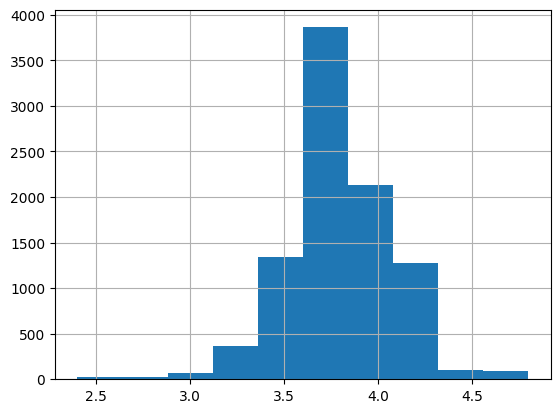

In [136]:
output['target'].hist()

# Время работы
Эмбединг large модели генерируются около часа. Анализ сентимента ~20 минут. Остальная часть решения с учётом, что препъдыдущие данные уже получены ~50 минут